#  Digital Payment Systems Analysis in India using RBI Data

This project analyzes digital payment trends in India using RBI and UPI datasets.  
It focuses on comparing different payment systems such as UPI, NEFT, RTGS, IMPS, and AEPS to understand growth patterns, transaction volume, and adoption trends over time.


## Problem Statement

Analyze RBI digital payment data to compare different payment systems (NEFT, RTGS, IMPS, etc.) and identify trends in transaction volume and value over time.

# Data Loading

In [ ]:
#Load RBI payment Dataset

import pandas as pd
df_daily = pd.read_csv('rbi_daily_digital_payments.csv')

print(df_daily.shape)
df_daily.head()

(1857, 50)


,Unnamed: 0,date,rtgs_vol,rtgs_val,neft_vol,neft_val,aeps_vol,aeps_val,upi_vol,upi_val,...,Unnamed: 40,Unnamed: 41,Unnamed: 42,Unnamed: 43,Unnamed: 44,Unnamed: 45,Unnamed: 46,Unnamed: 47,Unnamed: 48,Unnamed: 49
0,0,01-06-2020,4.85,436996.69,172.11,104275.13,0.44,7.68,476.97,10413.11,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,02-06-2020,4.54,361878.87,100.07,65259.02,0.44,7.67,476.78,9951.30,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,03-06-2020,4.30,330632.89,100.36,62985.75,0.44,7.48,456.26,9622.38,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,04-06-2020,4.35,329072.45,94.66,63148.29,0.45,7.32,463.05,9639.50,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,05-06-2020,4.56,365468.95,111.26,68932.72,0.48,7.32,464.79,9539.52,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Data Cleaning

In [9]:
dfB = df_daily.copy()

# Remove unwanted index column
dfB = dfB.loc[:, ~dfB.columns.str.contains('unnamed', case=False)]
dfB.head()


,date,rtgs_vol,rtgs_val,neft_vol,neft_val,aeps_vol,aeps_val,upi_vol,upi_val,imps_vol,...,netc_vol,netc_val,bbps_vol,bbps_val,cts_vol,cts_val,nfs_through_atms_vol,nfs_through_atms_val,aeps_through_micro_atms_or_bcs_vol,aeps_through_micro_atms_or_bcs_val
0,01-06-2020,4.85,436996.69,172.11,104275.13,0.44,7.68,476.97,10413.11,76.81,...,23.82,44.37,5.43,95.36,17.55,15056.24,105.82,4764.81,29.02,696.56
1,02-06-2020,4.54,361878.87,100.07,65259.02,0.44,7.67,476.78,9951.30,72.25,...,24.38,46.23,5.21,81.15,18.25,16041.19,105.13,4781.97,28.30,676.75
2,03-06-2020,4.30,330632.89,100.36,62985.75,0.44,7.48,456.26,9622.38,68.15,...,25.36,47.21,5.24,81.36,16.76,14536.47,99.49,4426.92,28.85,668.88
3,04-06-2020,4.35,329072.45,94.66,63148.29,0.45,7.32,463.05,9639.50,70.69,...,25.81,48.39,5.51,83.05,17.39,14865.92,101.38,4424.53,29.57,648.92
4,05-06-2020,4.56,365468.95,111.26,68932.72,0.48,7.32,464.79,9539.52,73.00,...,25.99,48.60,5.33,85.94,18.25,15214.06,101.19,4321.01,32.65,646.99


In [ ]:
#Clean Column Names

dfB.columns = (
    dfB.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("(", "", regex=False)
    .str.replace(")", "", regex=False)
    .str.replace(".", "", regex=False)
    .str.replace("-", "_", regex=False)
)

dfB.head()


,date,rtgs_vol,rtgs_val,neft_vol,neft_val,aeps_vol,aeps_val,upi_vol,upi_val,imps_vol,...,netc_vol,netc_val,bbps_vol,bbps_val,cts_vol,cts_val,nfs_through_atms_vol,nfs_through_atms_val,aeps_through_micro_atms_or_bcs_vol,aeps_through_micro_atms_or_bcs_val
0,01-06-2020,4.85,436996.69,172.11,104275.13,0.44,7.68,476.97,10413.11,76.81,...,23.82,44.37,5.43,95.36,17.55,15056.24,105.82,4764.81,29.02,696.56
1,02-06-2020,4.54,361878.87,100.07,65259.02,0.44,7.67,476.78,9951.30,72.25,...,24.38,46.23,5.21,81.15,18.25,16041.19,105.13,4781.97,28.30,676.75
2,03-06-2020,4.30,330632.89,100.36,62985.75,0.44,7.48,456.26,9622.38,68.15,...,25.36,47.21,5.24,81.36,16.76,14536.47,99.49,4426.92,28.85,668.88
3,04-06-2020,4.35,329072.45,94.66,63148.29,0.45,7.32,463.05,9639.50,70.69,...,25.81,48.39,5.51,83.05,17.39,14865.92,101.38,4424.53,29.57,648.92
4,05-06-2020,4.56,365468.95,111.26,68932.72,0.48,7.32,464.79,9539.52,73.00,...,25.99,48.60,5.33,85.94,18.25,15214.06,101.19,4321.01,32.65,646.99


In [11]:
# Convert date to Datetime

dfB['date'] = pd.to_datetime(dfB['date'], format='%d-%m-%Y', errors='coerce')
dfB['date'].head()


0   2020-06-01
1   2020-06-02
2   2020-06-03
3   2020-06-04
4   2020-06-05
Name: date, dtype: datetime64[ns]

# Data Type Conversion

In [ ]:
#Numeric Conversion

num_cols = [col for col in dfB.columns if col != 'date']

for col in num_cols:
    dfB[col] = dfB[col].astype(str).str.replace(",", "").str.strip()
    dfB[col] = pd.to_numeric(dfB[col], errors='coerce')

dfB.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1857 entries, 0 to 1856
Data columns (total 25 columns):
 #   Column                              Non-Null Count  Dtype         
---  ------                              --------------  -----         
 0   date                                1857 non-null   datetime64[ns]
 1   rtgs_vol                            1813 non-null   float64       
 2   rtgs_val                            1813 non-null   float64       
 3   neft_vol                            1857 non-null   float64       
 4   neft_val                            1857 non-null   float64       
 5   aeps_vol                            1857 non-null   float64       
 6   aeps_val                            1857 non-null   float64       
 7   upi_vol                             1857 non-null   float64       
 8   upi_val                             1857 non-null   float64       
 9   imps_vol                            1857 non-null   float64       
 10  imps_val                

In [ ]:
#Checking NUll Values

dfB.isnull().sum()

date                                    0
rtgs_vol                               44
rtgs_val                               44
neft_vol                                0
neft_val                                0
aeps_vol                                0
aeps_val                                0
upi_vol                                 0
upi_val                                 0
imps_vol                                0
imps_val                                0
nach_credit_vol                        95
nach_credit_val                        95
nach_debit_vol                         98
nach_debit_val                         98
netc_vol                                0
netc_val                                0
bbps_vol                                0
bbps_val                                0
cts_vol                               398
cts_val                               398
nfs_through_atms_vol                    0
nfs_through_atms_val                    0
aeps_through_micro_atms_or_bcs_vol

In [57]:
# Filling missing values with 0 assuming no transactions occurred.

dfB.fillna(0, inplace=True)
dfB.isnull().sum()

date                                  0
rtgs_vol                              0
rtgs_val                              0
neft_vol                              0
neft_val                              0
aeps_vol                              0
aeps_val                              0
upi_vol                               0
upi_val                               0
imps_vol                              0
imps_val                              0
nach_credit_vol                       0
nach_credit_val                       0
nach_debit_vol                        0
nach_debit_val                        0
netc_vol                              0
netc_val                              0
bbps_vol                              0
bbps_val                              0
cts_vol                               0
cts_val                               0
nfs_through_atms_vol                  0
nfs_through_atms_val                  0
aeps_through_micro_atms_or_bcs_vol    0
aeps_through_micro_atms_or_bcs_val    0


# Created structured time-based featires for analysis

In [14]:
dfB['year'] = dfB['date'].dt.year
dfB['month'] = dfB['date'].dt.month
dfB['month_name'] = dfB['date'].dt.strftime('%B')


In [ ]:
# to check column names after cleaning

dfB.columns

Index(['date', 'rtgs_vol', 'rtgs_val', 'neft_vol', 'neft_val', 'aeps_vol',
       'aeps_val', 'upi_vol', 'upi_val', 'imps_vol', 'imps_val',
       'nach_credit_vol', 'nach_credit_val', 'nach_debit_vol',
       'nach_debit_val', 'netc_vol', 'netc_val', 'bbps_vol', 'bbps_val',
       'cts_vol', 'cts_val', 'nfs_through_atms_vol', 'nfs_through_atms_val',
       'aeps_through_micro_atms_or_bcs_vol',
       'aeps_through_micro_atms_or_bcs_val', 'year', 'month', 'month_name'],
      dtype='object')

# Monthly Aggregation

In [ ]:
#Using only numeric columns

numeric_cols = dfB.select_dtypes(include=['float64', 'int64']).columns

monthly_df = dfB.groupby(['year', 'month'])[numeric_cols].sum().reset_index()

monthly_df['date'] = pd.to_datetime(
    monthly_df['year'].astype(str) + '-' + monthly_df['month'].astype(str) + '-01'
)

monthly_df.head()


,year,month,rtgs_vol,rtgs_val,neft_vol,neft_val,aeps_vol,aeps_val,upi_vol,upi_val,...,netc_val,bbps_vol,bbps_val,cts_vol,cts_val,nfs_through_atms_vol,nfs_through_atms_val,aeps_through_micro_atms_or_bcs_vol,aeps_through_micro_atms_or_bcs_val,date
0,2020,6,119.68,8651977.71,2274.00,1906586.11,15.55,232.91,13369.33,261835.51,...,1511.93,176.42,2969.67,496.38,401440.56,2903.72,118665.23,990.76,19748.97,2020-06-01
1,2020,7,124.78,8335279.06,2401.06,1963113.40,16.77,260.80,14973.54,290537.86,...,1623.46,201.57,3707.40,532.24,433799.37,2839.06,117726.63,743.40,17468.50,2020-07-01
2,2020,8,116.77,7292379.70,2346.10,1930552.40,20.35,299.45,16188.27,298307.62,...,1712.59,212.11,3782.47,519.73,425251.61,2976.69,121710.91,814.30,19512.86,2020-08-01
3,2020,9,130.09,9489065.74,2468.27,2165514.74,16.23,255.73,18001.67,329031.84,...,1940.61,231.86,3920.81,612.63,485114.45,3065.76,124333.42,717.66,17095.93,2020-09-01
4,2020,10,138.19,8496045.74,2761.64,2235388.65,11.57,248.61,20716.19,386106.74,...,2137.16,237.22,3961.44,643.08,524090.34,3399.34,141160.60,720.68,18354.47,2020-10-01


# Identified key payment systems

In [ ]:
#key payment modes

col_rtgs = [c for c in dfB.columns if 'rtgs_vol' in c]
col_neft = [c for c in dfB.columns if 'neft_vol' in c]
col_imps = [c for c in dfB.columns if 'imps_vol' in c]
col_aeps = [c for c in dfB.columns if 'aeps_vol' in c]
col_upi  = [c for c in dfB.columns if 'upi_vol' in c]

col_rtgs, col_neft, col_imps, col_aeps, col_upi


(['rtgs_vol'], ['neft_vol'], ['imps_vol'], ['aeps_vol'], ['upi_vol'])

# Trend analysis

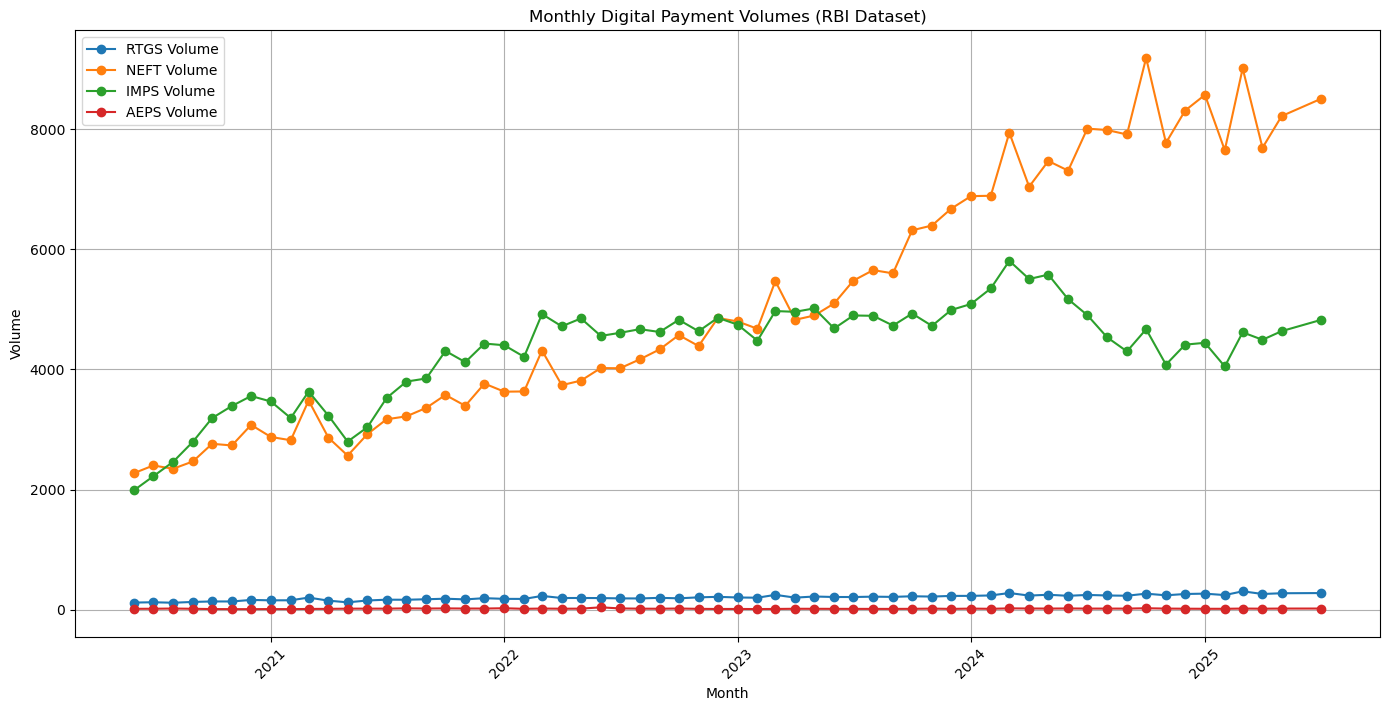

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))

if col_rtgs:
    plt.plot(monthly_df['date'], monthly_df[col_rtgs[0]], label='RTGS Volume', marker='o')

if col_neft:
    plt.plot(monthly_df['date'], monthly_df[col_neft[0]], label='NEFT Volume', marker='o')

if col_imps:
    plt.plot(monthly_df['date'], monthly_df[col_imps[0]], label='IMPS Volume', marker='o')

if col_aeps:
    plt.plot(monthly_df['date'], monthly_df[col_aeps[0]], label='AEPS Volume', marker='o')

plt.title("Monthly Digital Payment Volumes (RBI Dataset)")
plt.xlabel("Month")
plt.ylabel("Volume")
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.xticks(rotation=45)
plt.show()


# Growth Analysis

In [18]:
monthly_df['rtgs_growth_%'] = monthly_df[col_rtgs[0]].pct_change() * 100
monthly_df['neft_growth_%'] = monthly_df[col_neft[0]].pct_change() * 100
monthly_df['imps_growth_%'] = monthly_df[col_imps[0]].pct_change() * 100
monthly_df['aeps_growth_%'] = monthly_df[col_aeps[0]].pct_change() * 100

monthly_df[['date', 'rtgs_growth_%', 'neft_growth_%', 'imps_growth_%', 'aeps_growth_%']].head()


,date,rtgs_growth_%,neft_growth_%,imps_growth_%,aeps_growth_%
0,2020-06-01,NaN,NaN,NaN,NaN
1,2020-07-01,4.261364,5.587511,11.655230,7.845659
2,2020-08-01,-6.419298,-2.288989,10.817248,21.347645
3,2020-09-01,11.407039,5.207365,13.604525,-20.245700
4,2020-10-01,6.226459,11.885653,14.078281,-28.712261


# UPI data integration

In [ ]:
# Load UPI dataset again in THIS notebook

dfA = pd.read_csv('upi_monthly_payments.csv')

dfA.head()



,Month,Volume (In Mn.),Avg. Daily Volume (In Mn.),Value (In Cr.),Avg. Daily Value (In Cr.)
0,December-2025,2854.73,713.6837,435495.60,108873.9000
1,November-2025,20466.98,682.2326,2631632.64,87721.0880
2,October-2025,20700.92,667.7716,2727790.71,87993.2487
3,September-2025,19633.43,654.4478,2489736.52,82991.2173
4,August-2025,20008.31,645.4294,2485472.90,80176.5452


In [20]:
dfA.columns = (dfA.columns
               .str.strip()
               .str.lower()
               .str.replace(" ", "_")
               .str.replace("(", "", regex=False)
               .str.replace(")", "", regex=False)
               .str.replace(".", "", regex=False))


In [21]:
dfA['month'] = pd.to_datetime(dfA['month'], format='%B-%Y')
dfA.sort_values('month', inplace=True)


In [22]:
numeric_cols_A = [
    'volume_in_mn',
    'avg_daily_volume_in_mn',
    'value_in_cr',
    'avg_daily_value_in_cr'
]

for col in numeric_cols_A:
    dfA[col] = dfA[col].astype(str).str.replace(",", "")
    dfA[col] = pd.to_numeric(dfA[col], errors='coerce')


# Merging Datasets ( RBI and UPI )

In [23]:

df_modes = monthly_df[['date', col_rtgs[0], col_neft[0], col_imps[0], col_aeps[0]]]

df_upi = dfA[['month', 'volume_in_mn']].copy()
df_upi.rename(columns={'month': 'date', 'volume_in_mn': 'upi_volume_mn'}, inplace=True)

combined_df = pd.merge(df_modes, df_upi, on='date', how='left')

combined_df.head()


,date,rtgs_vol,neft_vol,imps_vol,aeps_vol,upi_volume_mn
0,2020-06-01,119.68,2274.00,1989.15,15.55,NaN
1,2020-07-01,124.78,2401.06,2220.99,16.77,NaN
2,2020-08-01,116.77,2346.10,2461.24,20.35,NaN
3,2020-09-01,130.09,2468.27,2796.08,16.23,NaN
4,2020-10-01,138.19,2761.64,3189.72,11.57,NaN


In [24]:
dfA['month'].min(), dfA['month'].max()


(Timestamp('2025-04-01 00:00:00'), Timestamp('2025-12-01 00:00:00'))

In [25]:
# Filtering combined dataset for UPI volume analysis

combined_df_filtered = combined_df.dropna(subset=['upi_volume_mn'])
combined_df_filtered.head()


,date,rtgs_vol,neft_vol,imps_vol,aeps_vol,upi_volume_mn
58,2025-04-01,262.39,7687.50,4492.53,17.69,17893.42
59,2025-05-01,274.70,8215.46,4636.60,19.82,18677.45
60,2025-07-01,277.68,8500.13,4821.90,20.26,19467.95


# Comparative Analysis 

Compared UPI with traditional systems like IMPS, NEFT, and RTGS to analyze differences in transaction volume and growth trends.

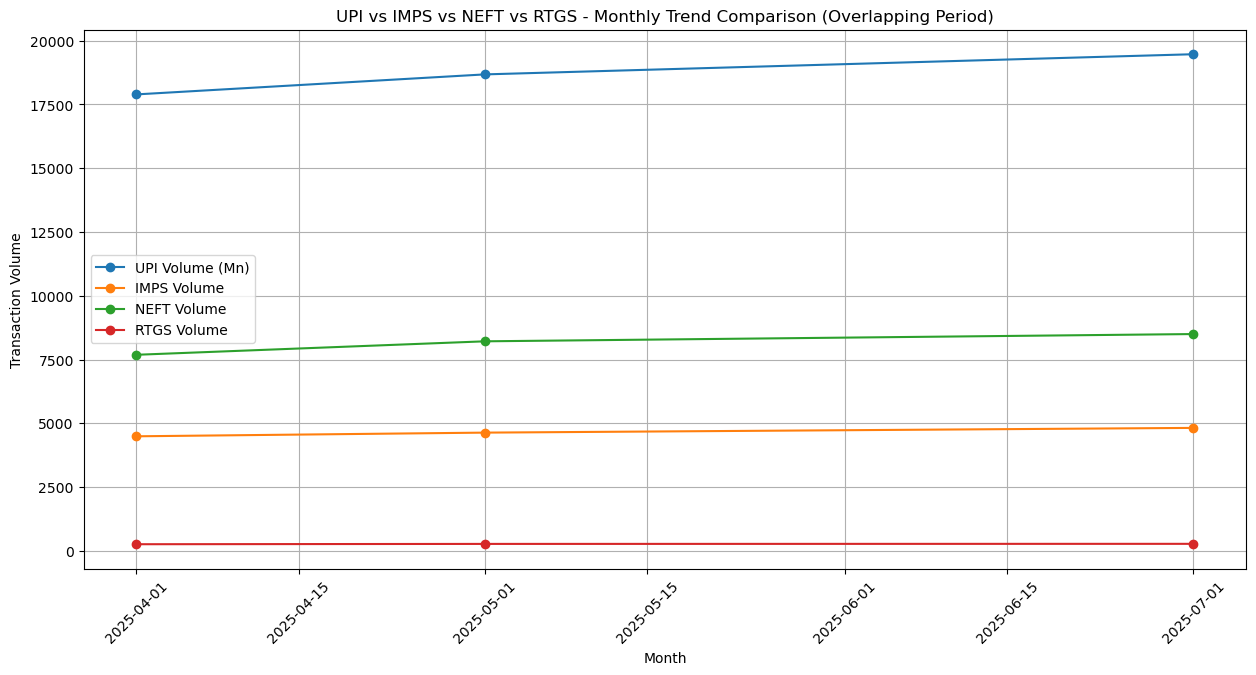

In [26]:
plt.figure(figsize=(15, 7))

plt.plot(combined_df_filtered['date'], combined_df_filtered['upi_volume_mn'], label='UPI Volume (Mn)', marker='o')
plt.plot(combined_df_filtered['date'], combined_df_filtered[col_imps[0]], label='IMPS Volume', marker='o')
plt.plot(combined_df_filtered['date'], combined_df_filtered[col_neft[0]], label='NEFT Volume', marker='o')
plt.plot(combined_df_filtered['date'], combined_df_filtered[col_rtgs[0]], label='RTGS Volume', marker='o')

plt.title("UPI vs IMPS vs NEFT vs RTGS - Monthly Trend Comparison (Overlapping Period)")
plt.xlabel("Month")
plt.ylabel("Transaction Volume")
plt.grid(True)
plt.legend()
plt.xticks(rotation=45)
plt.show()


In [ ]:
# Save cleaned monthly dataset for further analysis

monthly_df.to_csv('rbi_monthly_cleaned.csv', index=False)

# Advanced Analysis

# Market Share Calculation

In [54]:
# Share of each payment mode in total digital volume

modes = ['upi_vol', 'imps_vol', 'neft_vol', 'rtgs_vol', 'aeps_vol']
monthly_df['total_digital_vol'] = monthly_df[modes].sum(axis=1)
monthly_df['total_digital_vol'] = monthly_df['total_digital_vol'].replace(0, 1)


for m in modes:
    monthly_df[m + '_share_%'] = (
    (monthly_df[m] / monthly_df['total_digital_vol']) * 100    
    ).round(2)

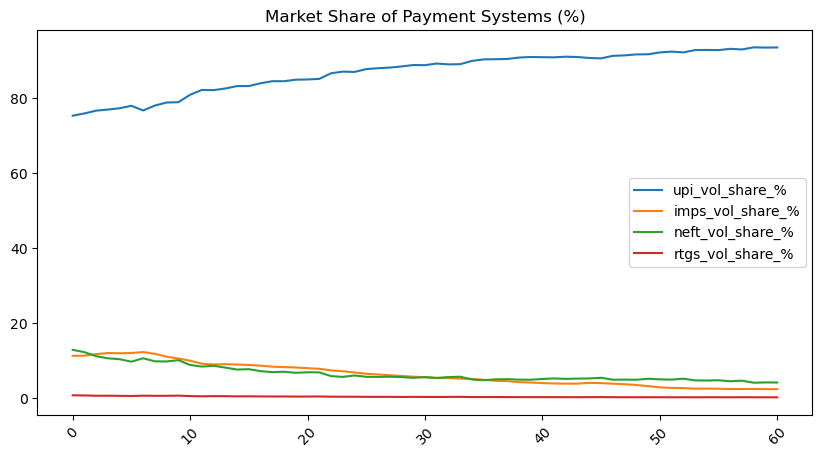

In [55]:
# Plotting the share of each payment mode over time

monthly_df[['upi_vol_share_%', 'imps_vol_share_%', 'neft_vol_share_%', 'rtgs_vol_share_%']].plot(figsize=(10,5))
plt.title("Market Share of Payment Systems (%)")
plt.xticks(rotation=45)
plt.show()



# Yearly Summary

In [52]:
# Year-wise summary table

yearly_summary = monthly_df.groupby('year')[['upi_vol', 'imps_vol', 'neft_vol', 'rtgs_vol']].sum()
yearly_summary = yearly_summary.sort_index()

yearly_summary

,upi_vol,imps_vol,neft_vol,rtgs_vol
year,,,,
2020,127692.87,19605.27,18061.32,930.81
2021,387331.41,43380.89,38008.83,2003.50
2022,740396.89,55869.91,49480.22,2364.49
2023,1176087.55,58006.51,65871.24,2605.11
2024,1722080.18,59383.40,92684.34,2952.87
2025,1074425.34,27057.94,49627.95,1634.16


# Weekday Analysis

In [37]:
# Analyzing if there are differences in UPI transaction volumes on weekdays vs weekends

dfB['weekday'] = dfB['date'].dt.day_name()
weekday_summary = dfB.groupby('weekday')['upi_vol'].sum().reindex(
    ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
)


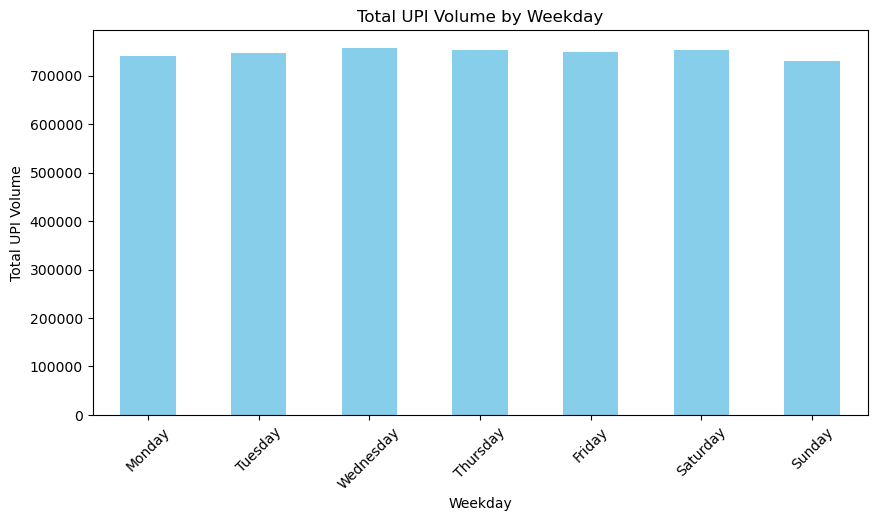

In [47]:
# Plotting weekday vs weekend UPI volumes
plt.figure(figsize=(10,5))
weekday_summary.plot(kind='bar', color='skyblue')
plt.title("Total UPI Volume by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Total UPI Volume")
plt.xticks(rotation=45)
plt.show()


# Rolling Average

In [ ]:
# Rolling average to smooth the daily noise

upi_daily = dfB[['date', 'upi_vol']].set_index('date').sort_index()
upi_daily['upi_7d_ma'] = upi_daily['upi_vol'].rolling(window=7).mean()


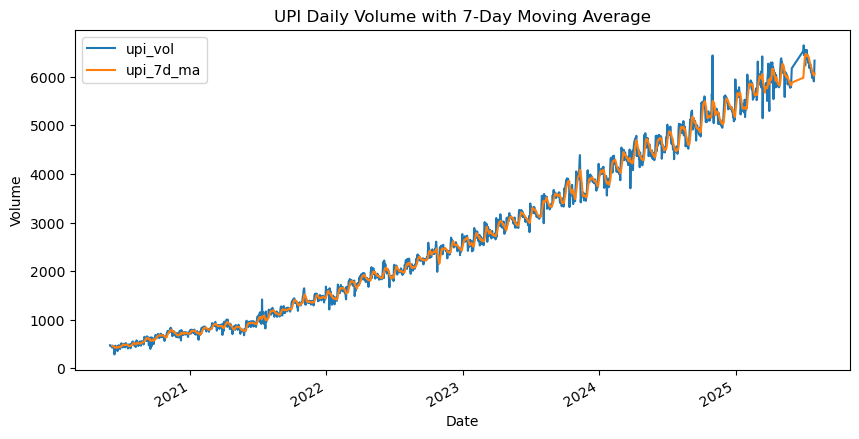

In [50]:
# plotting daily UPI volume with 7-day moving average

upi_daily[['upi_vol', 'upi_7d_ma']].plot(figsize=(10,5))
plt.title("UPI Daily Volume with 7-Day Moving Average")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.legend()
plt.show()

## Key Insights

- UPI dominates digital payment volume compared to traditional systems  
- NEFT and RTGS show steady but slower growth trends  
- IMPS shows moderate growth but remains below UPI  
- Digital payment adoption has increased significantly over time  
- UPI growth accelerates rapidly compared to other systems  
- Weekday analysis indicates higher transaction activity on working days  
- Rolling average shows consistent upward trend in digital payments  

# Conclusion

The analysis highlights a strong shift towards digital payment systems in India, with UPI emerging as the dominant mode. Traditional systems such as NEFT and RTGS continue to grow but at a slower pace, indicating a transition towards a digital-first financial ecosystem.